This notebook examines what size flare is required in order to meet our science goals.
1. The attenuated spectra are used to compute the effective area required to meet the goals
2. An effective area is assumed and the expected photon rates are computed

Note that this notebook uses data not included in the Git repo, so you will need to run `mcmurdo_station_attenuation.py` for various flare magnitudes in order to use the full functionality of this notebook.

In [2]:
import os
import pickle
from typing import cast

import astropy.units as u
import impish_stack
import matplotlib.pyplot as plt
import numpy as np

from adetsim import flares
from adetsim.atmosphere import generate_flare_spectrum, plot_spectrum, style_file

/home/reed/Documents/research/impish/cubesat-analytical-detector-sim/adetsim/flares.py:5: SunpyDeprecationWarning: The legacy module has been deprecated since version 0.4 and will be removed in a future version.
  from sunkit_spex.legacy import photon_power_law, thermal


In [3]:
def filter_histogram_bins(
    values: u.Quantity, bins: u.Quantity, start: u.Quantity, end: u.Quantity
) -> tuple[u.Quantity, u.Quantity]:
    """
    Filters histogram bins to contain only bins within the specified range.
    Returns values, bins.
    """
    widths = bins[1:] - bins[:-1]
    mids = bins[:-1] + widths / 2
    mindex = (mids >= start) & (mids <= end)

    corresponding_bins = np.concatenate(
        ((mids - widths / 2)[mindex], [(mids + widths / 2)[mindex][-1]])
    )
    return values[mindex], corresponding_bins

# Transmission probability through atmosphere

This plot shows the fraction of flare photons that transmit from the top of the atmosphere down to 40 km.
The absorption through the atmosphere is agnostic to flare class (given our model assumptions).

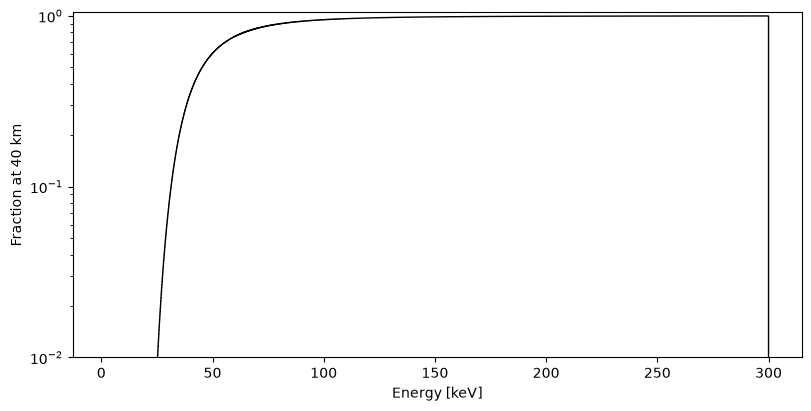

In [ ]:
in_dir = "./mcmurdo-station-attenuation"
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
colors = plt.cm.rainbow(np.linspace(0, 1, len(flare_classes)))

flare = "X1"
file = os.path.join(in_dir, f"{flare}-layer-attenuation-zenith54.8deg/transmissions.pkl")
with open(file, "rb") as infile:
    data = pickle.load(infile)
    layers = data["layers"]
    cumulative = np.ones_like(layers[0][1])
    for (altitude, transmission) in layers:
        cumulative *= transmission
        if altitude <= final_depth:
            break

edges = data["input"].energy_edges
ax.stairs(cumulative, edges.to_value(u.keV), color="black")
ax.set(
    xlabel="Energy [keV]",
    ylabel=f"Fraction at {final_depth} km",
    ylim=(1e-2, ax.get_ylim()[1]),
    yscale="log",
)
plt.show()

# Effective area for flares

Requires that simulated spectra be computed for **C1, C5, M1, M5, X1, X5, and X9 flares**.
The effective area required to meet Trevor's timing definition is computed for pre-defined energy bins for each flare magnitude.
This does **NOT** account for detection efficiency; this is purely examining *photon* rates, **NOT** *count* rates.

Flare class: X9
20.0 keV - 100.0 keV : 1747.6863939223094 ph / (s cm2)
effective area needed to meet science requirements energy range 20.0 keV - 100.0 keV: 0.71408692334048 cm2
30.0 keV - 300.0 keV : 2090.6509636872697 ph / (s cm2)
effective area needed to meet science requirements energy range 30.0 keV - 300.0 keV: 0.5969432591459022 cm2


Flare class: X5
20.0 keV - 100.0 keV : 777.3437063752003 ph / (s cm2)
effective area needed to meet science requirements energy range 20.0 keV - 100.0 keV: 1.6054674267828035 cm2
30.0 keV - 300.0 keV : 902.7045657697329 ph / (s cm2)
effective area needed to meet science requirements energy range 30.0 keV - 300.0 keV: 1.382512116725404 cm2


Flare class: X1
20.0 keV - 100.0 keV : 81.52692302815562 ph / (s cm2)
effective area needed to meet science requirements energy range 20.0 keV - 100.0 keV: 15.307826588389686 cm2
30.0 keV - 300.0 keV : 87.43359827624151 ph / (s cm2)
effective area needed to meet science requirements energy range 30.0 keV - 300.0

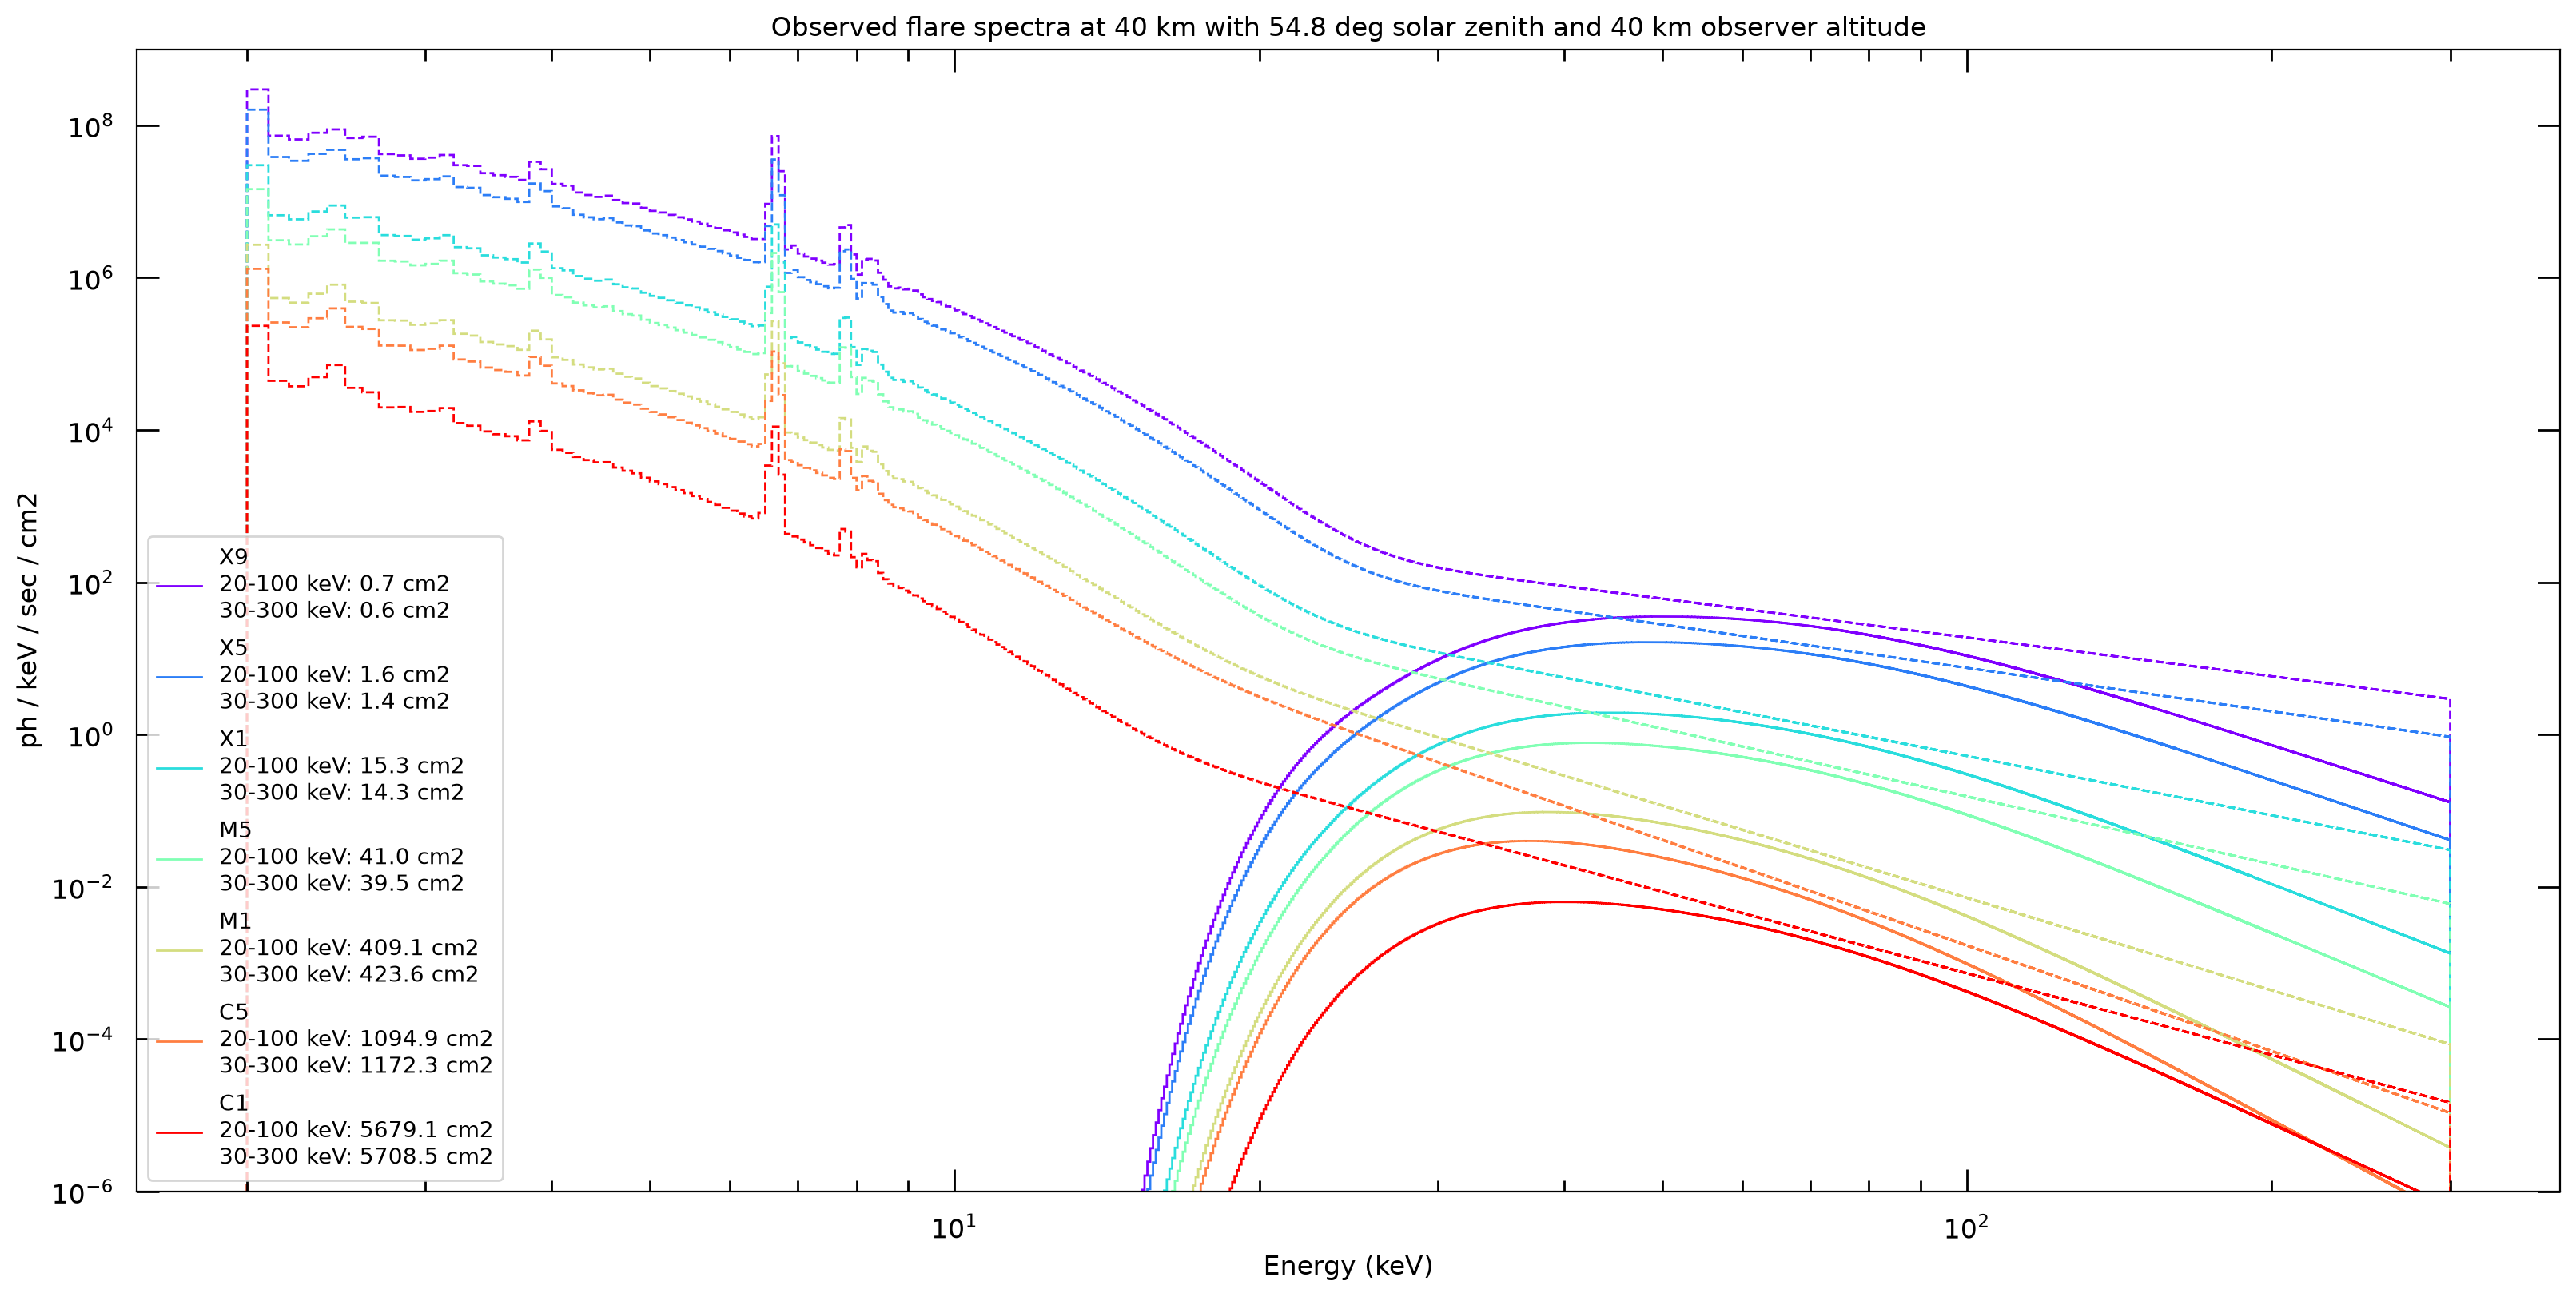

In [7]:
%matplotlib inline

in_dir = "./mcmurdo-station-attenuation"
flare_classes = ["C1", "C5", "M1", "M5", "X1", "X5", "X9"]
colors = plt.cm.rainbow(np.linspace(0, 1, len(flare_classes)))

final_depth = 40  # km

with plt.style.context(style_file):
    fig, ax = plt.subplots(figsize=(16, 8), layout="constrained")

for i, flare_class in enumerate(reversed(flare_classes)):
    print("Flare class:", flare_class)
    file = os.path.join(
        in_dir, f"{flare_class}-layer-attenuation-zenith54.8deg/transmissions.pkl"
    )
    with open(file, "rb") as infile:
        transmission_data = pickle.load(infile)

    flare: flares.Flare = transmission_data["input"]
    # Generate the approximate IMPISH response we will have
    impish_response_vec = impish_stack.generate("yap").compute_absorption(
        flare.energy_edges
    )

    cumulative = np.ones_like(transmission_data["layers"][0][1])
    for altitude, transmission in transmission_data["layers"]:
        cumulative *= transmission
        if altitude <= final_depth:
            break
    attenuated = cast(u.Quantity, flare.all_emission * cumulative) * impish_response_vec

    label = flare_class
    ranges = [(20, 100), (30, 300)] << u.keV
    for ea, eb in ranges:
        edges = flare.energy_edges
        filt_spectrum, filt_edges = filter_histogram_bins(attenuated, edges, ea, eb)

        cpspa = np.sum(filt_spectrum * np.diff(filt_edges)) << (u.ph / u.cm**2 / u.s)
        print(f"{ea} - {eb} : {cpspa}")

        eff_area = (156 << u.ph) / (cpspa * (1 / 8 << u.s))
        print(
            f"effective area needed to meet science requirements energy range {ea} - {eb}:",
            eff_area,
        )

        label += f"\n{ea.value:.0f}-{eb.value:.0f} {ea.unit}: {eff_area.value:.1f} {eff_area.unit}"
    print("\n")

    plot_spectrum(
        attenuated,
        flare.energy_edges,
        goes=flare_class,
        ax=ax,
        color=colors[i],
        label=label,
    )
    plot_spectrum(
        flare.all_emission,
        flare.energy_edges,
        goes=flare_class,
        ax=ax,
        color=colors[i],
        ls="--",
    )

ax.set_title(
    f"Observed flare spectra at {final_depth} km with 54.8 deg solar zenith and 40 km observer altitude"
)
ax.legend()

plt.savefig(os.path.join(in_dir, "effective_area_requirements.png"))
plt.show()
plt.close("all")

# Photon rates

Compute the photons rates expected from an assumed effective area.

## Total photon rates per flare

Flare class: X9
Flare class: X5
Flare class: X1
Flare class: M5
Flare class: M1
Flare class: C5
Flare class: C1


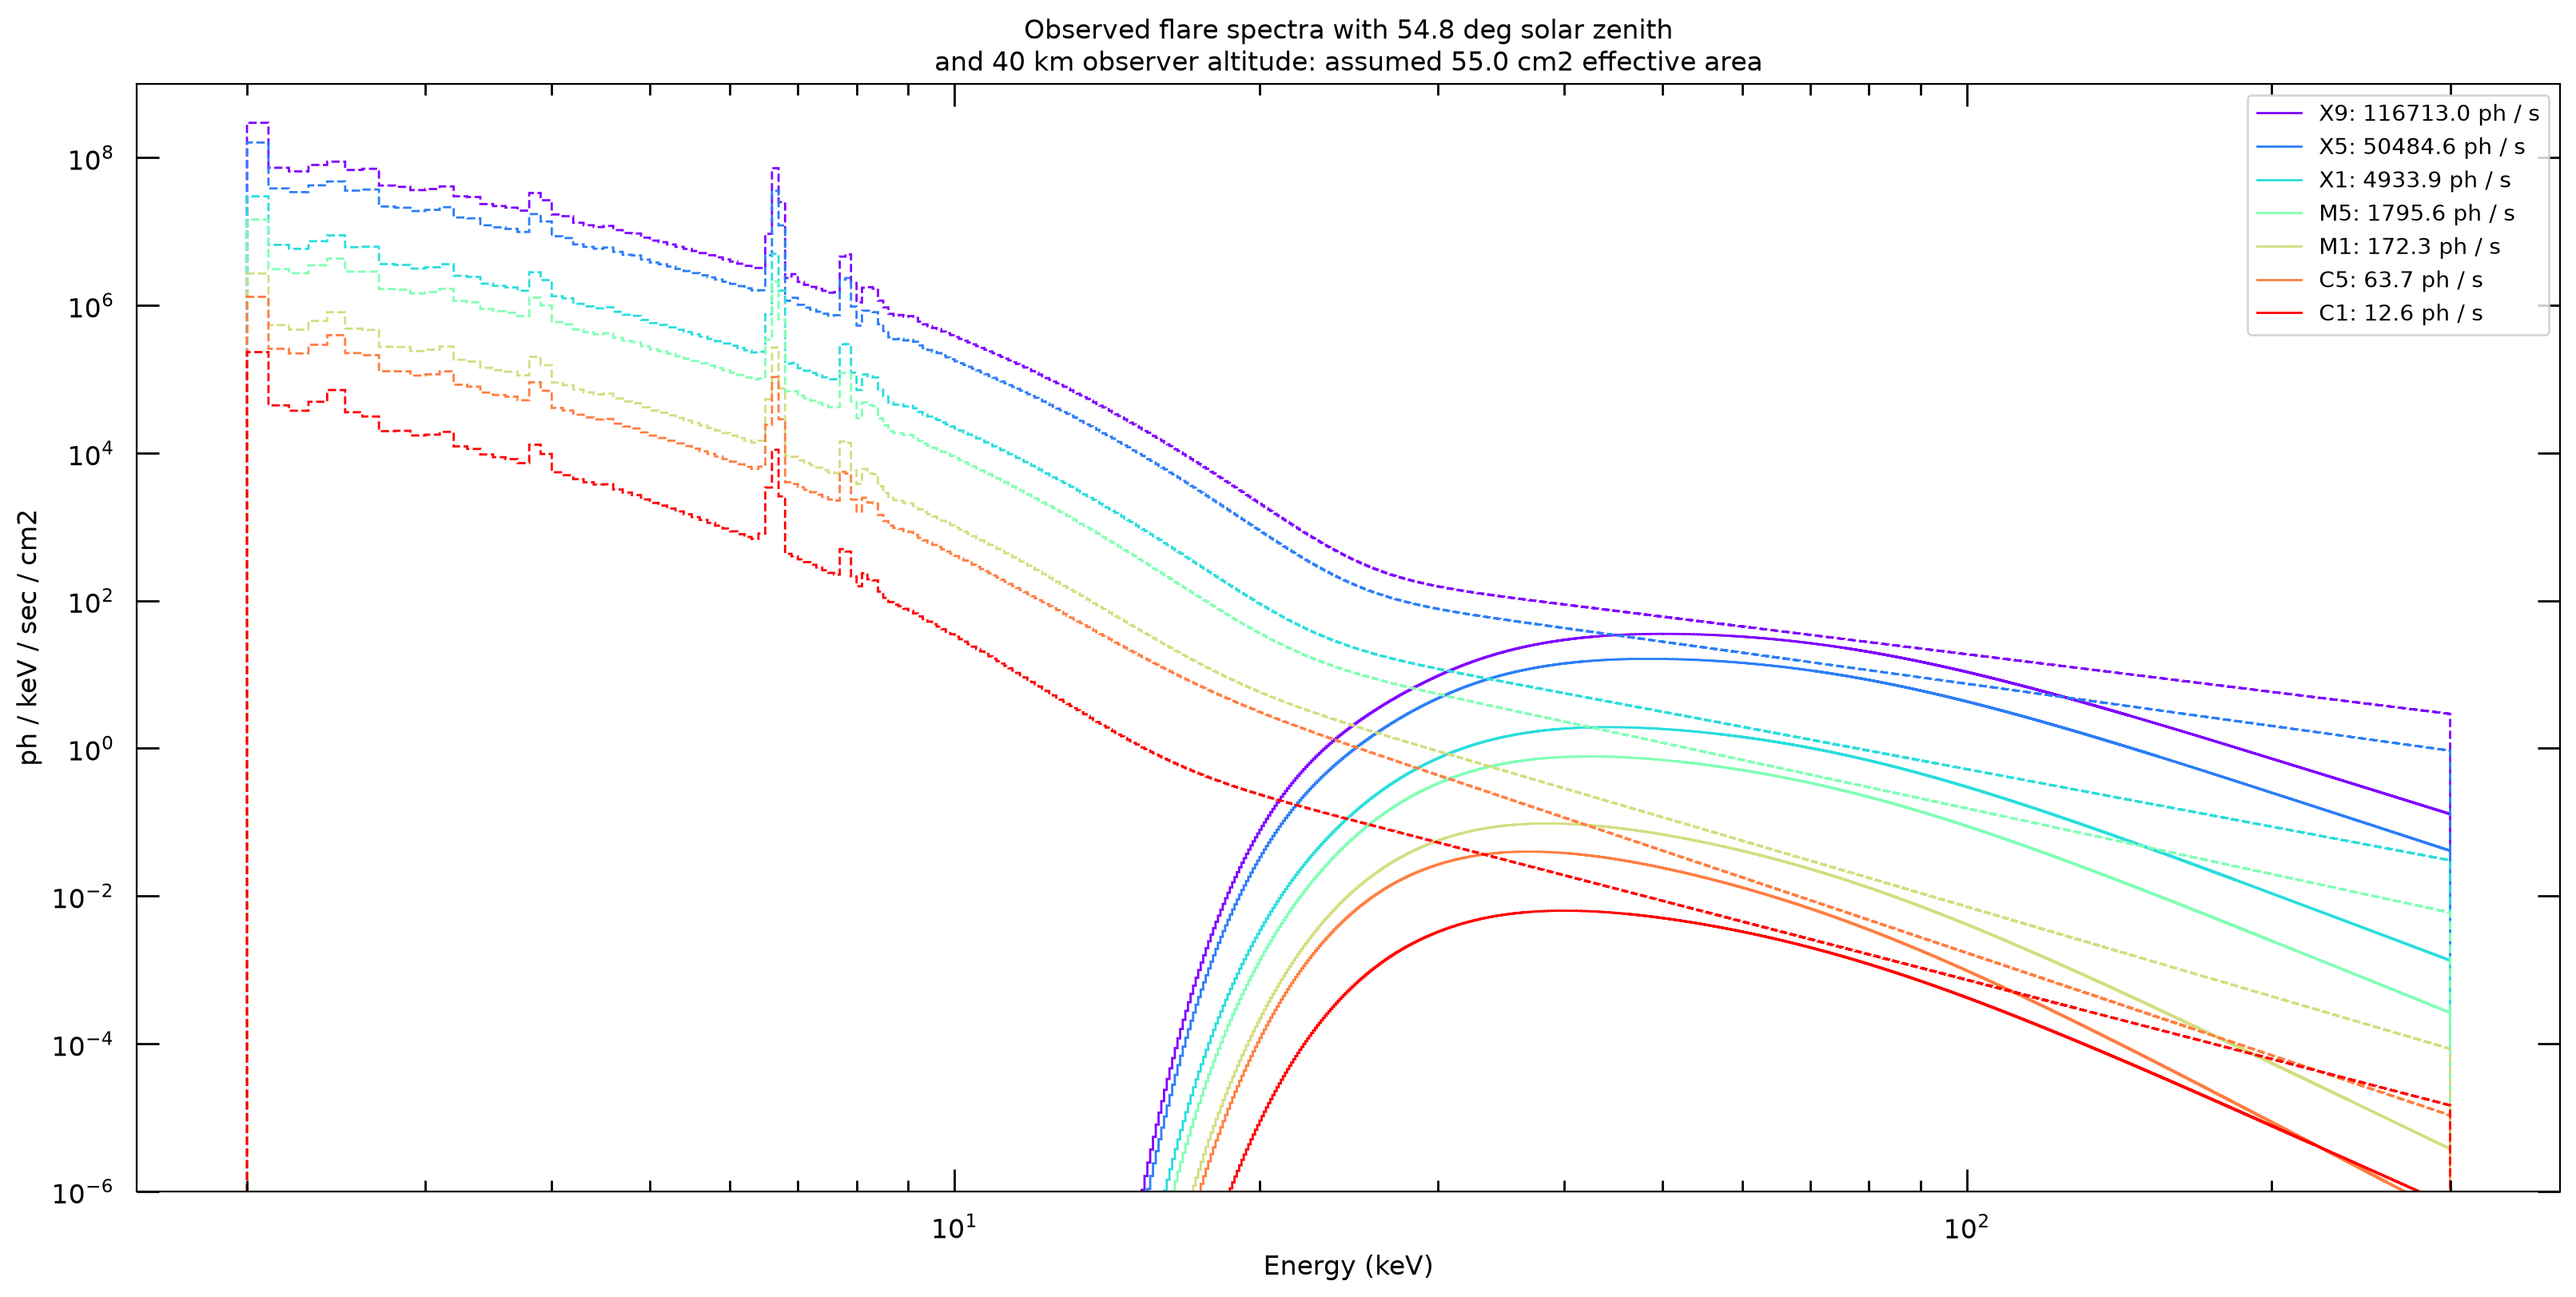

In [21]:
%matplotlib inline

effective_area = 55 * (u.cm) ** 2
flare_classes = ["C1", "C5", "M1", "M5", "X1", "X5", "X9"]
with plt.style.context(style_file):
    fig, ax = plt.subplots(figsize=(16, 8), layout="constrained")
colors = plt.cm.rainbow(np.linspace(0, 1, len(flares)))

for i, flare_class in enumerate(reversed(flare_classes)):
    print("Flare class:", flare_class)
    file = os.path.join(
        in_dir, f"{flare_class}-layer-attenuation-zenith54.8deg/transmissions.pkl"
    )
    with open(file, "rb") as infile:
        transmission_data = pickle.load(infile)

    flare: flares.Flare = transmission_data["input"]
    impish_response_vec = impish_stack.generate("yap").compute_absorption(
        flare.energy_edges
    )

    cumulative = np.ones_like(transmission_data["layers"][0][1])
    for altitude, transmission in transmission_data["layers"]:
        cumulative *= transmission
        if altitude <= final_depth:
            break
    attenuated = cast(u.Quantity, flare.all_emission * cumulative) * impish_response_vec

    edges = flare.energy_edges
    plate_xray_cps = attenuated * np.diff(edges) * effective_area
    label = f"{flare_class}: {np.sum(plate_xray_cps):0.1f}"

    plot_spectrum(
        attenuated,
        flare.energy_edges,
        goes=flare_class,
        ax=ax,
        color=colors[i],
        label=label,
    )
    plot_spectrum(
        flare.all_emission,
        flare.energy_edges,
        goes=flare_class,
        ax=ax,
        color=colors[i],
        ls="--",
    )

ax.set_title(
    f"Observed flare spectra with 54.8 deg solar zenith\nand 40 km observer altitude: assumed {(effective_area<<u.cm**2).value} cm2 effective area"
)
ax.legend()
plt.savefig(os.path.join(in_dir, "count_rates.png"))
plt.show()

## Photon rates per energy band

Flare class: X9
Flare class: X5
Flare class: X1
Flare class: M5
Flare class: M1
Flare class: C5
Flare class: C1


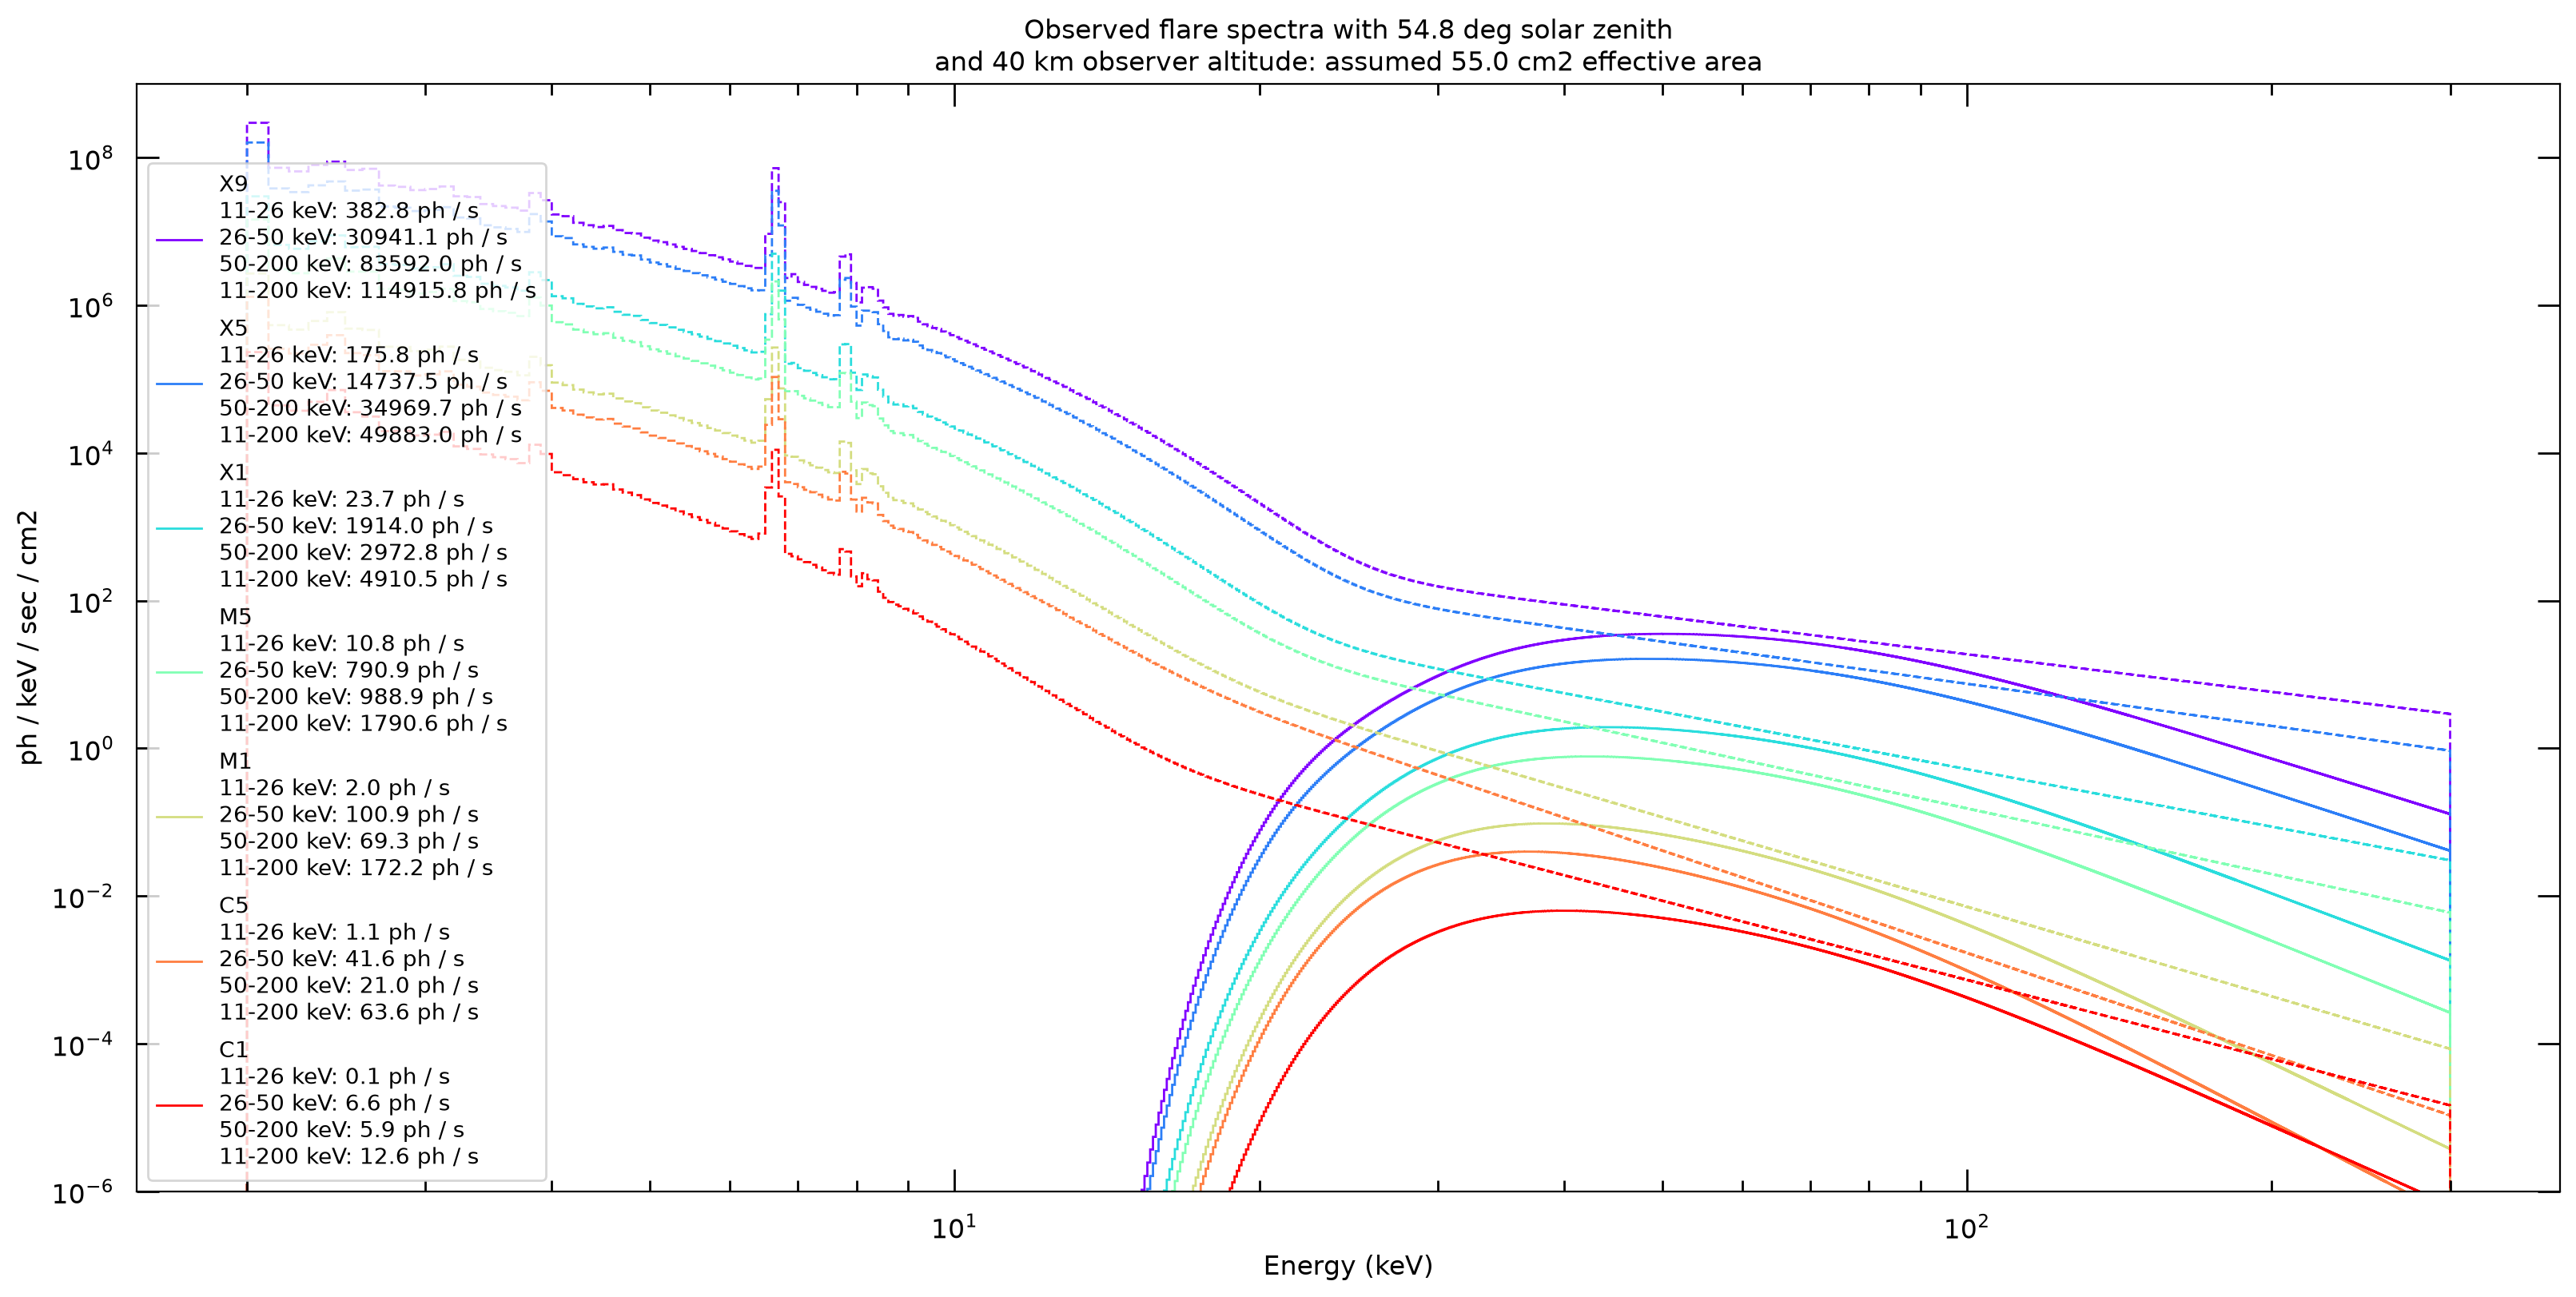

In [28]:
flare_classes = ["C1", "C5", "M1", "M5", "X1", "X5", "X9"]
colors = plt.cm.rainbow(np.linspace(0, 1, len(flares)))
with plt.style.context(style_file):
    fig, ax = plt.subplots(figsize=(16, 8), layout="constrained")

for i, flare_class in enumerate(reversed(flare_classes)):
    print("Flare class:", flare_class)
    file = os.path.join(
        in_dir, f"{flare_class}-layer-attenuation-zenith54.8deg/transmissions.pkl"
    )
    with open(file, "rb") as infile:
        transmission_data = pickle.load(infile)

    flare: flares.Flare = transmission_data["input"]
    impish_response_vec = impish_stack.generate("yap").compute_absorption(
        flare.energy_edges
    )
    cumulative = np.ones_like(transmission_data["layers"][0][1])
    for altitude, transmission in transmission_data["layers"]:
        cumulative *= transmission
        if altitude <= final_depth:
            break
    attenuated = cast(u.Quantity, flare.all_emission * cumulative) * impish_response_vec



    label = f"{flare_class}"
    # ranges = [ (10, 40) * u.keV, (40, 80) * u.keV, (80, 300) * u.keV, (10, 300) * u.keV]
    ranges = [(11, 26) * u.keV, (26, 50) * u.keV, (50, 200) * u.keV, (11, 200) * u.keV]
    for energy_range in ranges:
        edges = flare.energy_edges
        filt_spectrum, filt_edges = filter_histogram_bins(
            attenuated, edges, *energy_range
        )

        filt_edges = filt_edges
        plate_xray_cps = np.sum(filt_spectrum * np.diff(filt_edges) * effective_area)

        label += f"\n{energy_range[0].value:.0f}-{energy_range[1].value:.0f} {energy_range[0].unit}: {plate_xray_cps.value:.1f} {plate_xray_cps.unit}"


    plot_spectrum(
        attenuated,
        flare.energy_edges,
        goes=flare_class,
        ax=ax,
        color=colors[i],
        label=label,
    )
    plot_spectrum(
        flare.all_emission,
        flare.energy_edges,
        goes=flare_class,
        ax=ax,
        color=colors[i],
        ls="--",
    )

ax.set_title(
    f"Observed flare spectra with 54.8 deg solar zenith\nand 40 km observer altitude: assumed {(effective_area<<u.cm**2).value} cm2 effective area"
)
ax.legend()
plt.savefig(os.path.join(in_dir, "count_rates_energy_bands.png"), dpi=400)
plt.show()

# Plotting attenuated flare

This is an example examining the M1-class flare.

## M1 flare

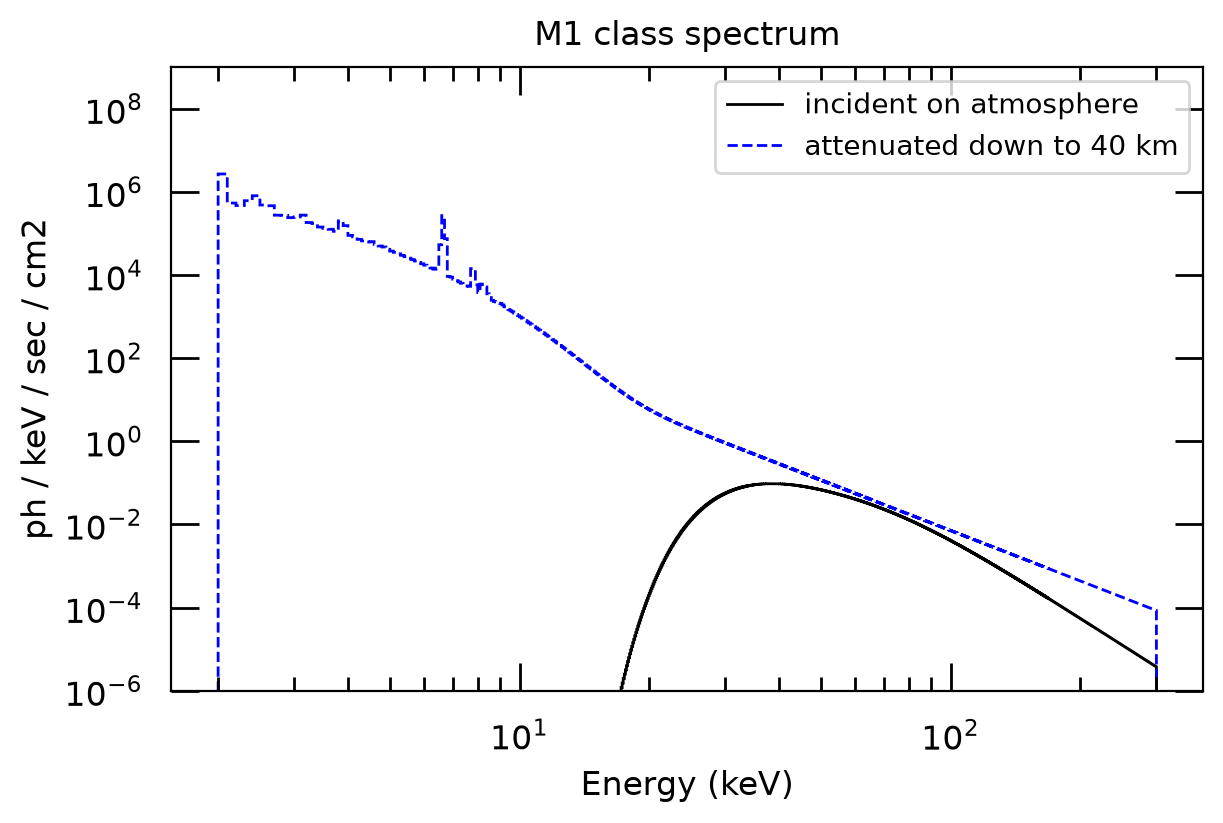

In [36]:
with plt.style.context(style_file):
    fig, ax = plt.subplots(figsize=(6,4), layout="constrained")
flare_class = "M1"
file = os.path.join(
    in_dir, f"{flare_class}-layer-attenuation-zenith54.8deg/transmissions.pkl"
)
with open(file, "rb") as infile:
    transmission_data = pickle.load(infile)

flare: flares.Flare = transmission_data["input"]
# Generate the approximate IMPISH response we will have
impish_response_vec = impish_stack.generate("yap").compute_absorption(
    flare.energy_edges
)
cumulative = np.ones_like(transmission_data["layers"][0][1])
for altitude, transmission in transmission_data["layers"]:
    cumulative *= transmission
    if altitude <= final_depth:
        break
attenuated = cast(u.Quantity, flare.all_emission * cumulative) * impish_response_vec

plot_spectrum(
    attenuated,
    flare.energy_edges,
    goes=flare_class,
    ax=ax,
    color="black",
    label="incident on atmosphere",
)
plot_spectrum(
    flare.all_emission,
    flare.energy_edges,
    goes=flare_class,
    ax=ax,
    color="blue",
    ls="--",
    label=f"attenuated down to {final_depth} km",
)
ax.legend()

## Minimum effective area

Checking Knuth thesis calculation

In [42]:
energy_range = (10, 200) * u.keV
edges = flare.energy_edges
filt_spectrum, filt_edges = filter_histogram_bins(attenuated, edges, *energy_range)
cpspa = np.sum(filt_spectrum * np.diff(filt_edges)) << (u.ph / u.cm**2 / u.s)

eff_area = 156 * u.ph / (cpspa * (1 / 16) * u.s)
print("photon rate:", cpspa)
print(
    f"effective area needed to meet science requirements for {energy_range[0]} - {energy_range[1]} for {flare_class} class flare:",
    eff_area,
)

photon rate: 3.131426665356918 ph / (s cm2)
effective area needed to meet science requirements for 10.0 keV - 200.0 keV for M1 class flare: 797.0807771465112 cm2
